In [15]:
import polars as pl

pdb_v = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_validation_triad.conf_af3.parquet"
)
cresta = pl.read_parquet("../../data/cresta/triad/staged/cresta_triad.conf_af3.parquet")

In [19]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
import numpy as np
import polars as pl
from sklearn.metrics import auc
import sklearn.metrics as metrics
from scipy.stats import pearsonr, spearmanr


def antigen_raw_score_summary(
    triad_dataset, featname, grouping_cols=FORMAT_ANTIGEN_COLS, mhc_class="I"
):

    antigens = triad_dataset.select(grouping_cols).unique()

    out_df = []

    for row in antigens.iter_rows(named=True):
        antigen = pl.DataFrame([row]).select(pl.exclude("job_name"))
        aucs = []
        focal_antigen_triads = triad_dataset.join(
            antigen, on=grouping_cols, nulls_equal=True
        )

        new_row = {}

        dat = focal_antigen_triads.select(featname, "cognate").to_numpy()

        fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
        roc_auc = metrics.auc(fpr, tpr)
        new_row["roc_auc"] = roc_auc
        new_row["fpr"] = fpr.tolist()
        new_row["tpr"] = tpr.tolist()
        if mhc_class == "I":
            new_row["name"] = row["mhc_1_name"] + "::" + row["peptide"]
        else:
            new_row["name"] = row["mhc_2_name"] + "::" + row["peptide"]
        out_df.append(new_row)

    summary_row = {}
    dat = triad_dataset.select(featname, "cognate").to_numpy()
    fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
    roc_auc = metrics.auc(fpr, tpr)
    summary_row["roc_auc"] = roc_auc
    summary_row["fpr"] = fpr.tolist()
    summary_row["tpr"] = tpr.tolist()
    summary_row["name"] = "All antigen"

    out_df.append(summary_row)

    return pl.DataFrame(out_df)

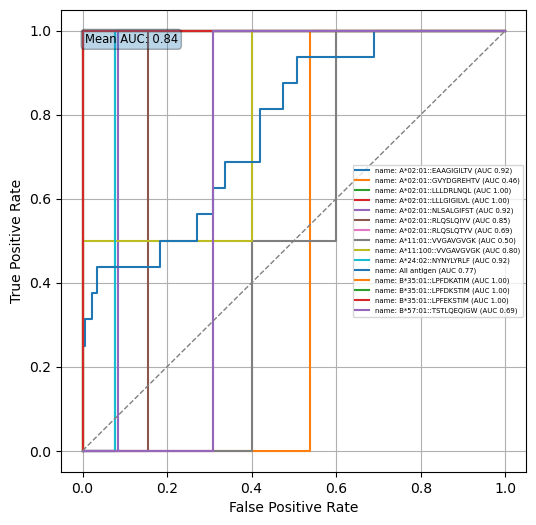

In [ ]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
from sklearn import metrics

auc_df = antigen_raw_score_summary(
    pdb_v.with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
    grouping_cols=["peptide", "mhc_1_name"],
    mhc_class="I",
)


ax = plot_auc_per_antigen(auc_df, id_cols=["name"])

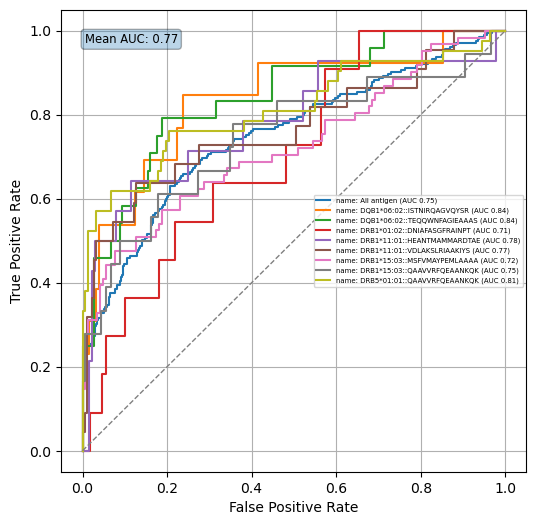

In [24]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
from sklearn import metrics

auc_df = antigen_raw_score_summary(
    cresta.with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
    mhc_class="II",
)


ax = plot_auc_per_antigen(auc_df, id_cols=["name"])

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

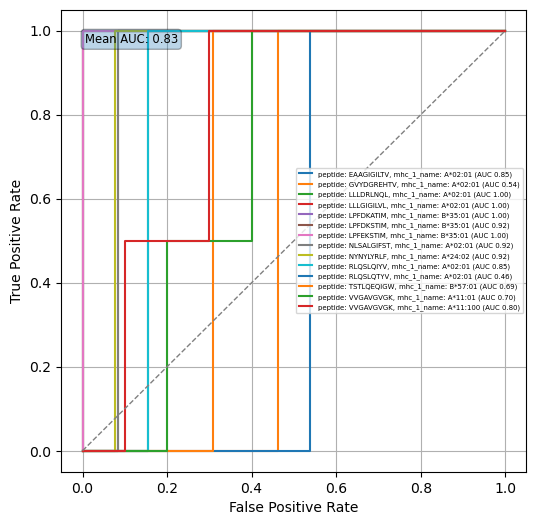

In [4]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

auc_df = antigen_raw_score_auc(
    pdb_v.with_columns(
        (1 - pl.col("mean_tcr_pmhc_interface_pae")).alias("mean_tcr_pmhc_interface_pae")
    ),
    "mean_tcr_pmhc_interface_pae",
    grouping_cols=["peptide", "mhc_1_name"],
)

plot_auc_per_antigen(auc_df, id_cols=["peptide", "mhc_1_name"])